In [259]:
import time
import sys
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scipy.stats as sps
import seaborn as sns
import statsmodels
import statsmodels.api as sm


from IPython.display import HTML, clear_output, display
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm

from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsforecast import models as sf_models
from statsforecast.models import SimpleExponentialSmoothing, SimpleExponentialSmoothingOptimized

# from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
# from statsmodels.tsa.seasonal import STL, seasonal_decompose
# from statsmodels.tsa.stattools import adfuller, kpss
# from torch import nn
# from torch.utils.data import DataLoader, Dataset, random_split
# from tsfresh import extract_features, select_features
# from tsfresh.feature_extraction import settings
# from tsfresh.utilities.dataframe_functions import impute, roll_time_series

# import pmdarima as pm
# import tsfresh
# from catboost import CatBoostRegressor
# from prophet import Prophet

from pylab import rcParams

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline

In [260]:
from sktime.registry import all_estimators

for forecaster in all_estimators(filter_tags={"scitype:y": ["multivariate", "both"]}):
    print(forecaster[0])

AutoTS
BaggingForecaster
ColumnEnsembleForecaster
DynamicFactor
ESRNNForecaster
EnsembleForecaster
FallbackForecaster
FhPlexForecaster
ForecastByLevel
ForecastKnownValues
ForecastX
ForecastingGridSearchCV
ForecastingOptunaSearchCV
ForecastingPipeline
ForecastingRandomizedSearchCV
ForecastingSkoptSearchCV
GroupbyCategoryForecaster
HierarchyEnsembleForecaster
IxToX
LTSFDLinearForecaster
LTSFLinearForecaster
LTSFNLinearForecaster
LTSFTransformerForecaster
MomentFMForecaster
MultiplexForecaster
PatchTSTForecaster
Permute
PluginParamsForecaster
SCINetForecaster
TinyTimeMixerForecaster
TransformSelectForecaster
TransformedTargetForecaster
VAR
VARMAX
VARReduce
VECM
YtoX


In [261]:
sys.path.append('/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional')

%load_ext autoreload
%autoreload 2

from utils.models import DummyConditionalModel, VARModel
from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error, visualize_ts
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


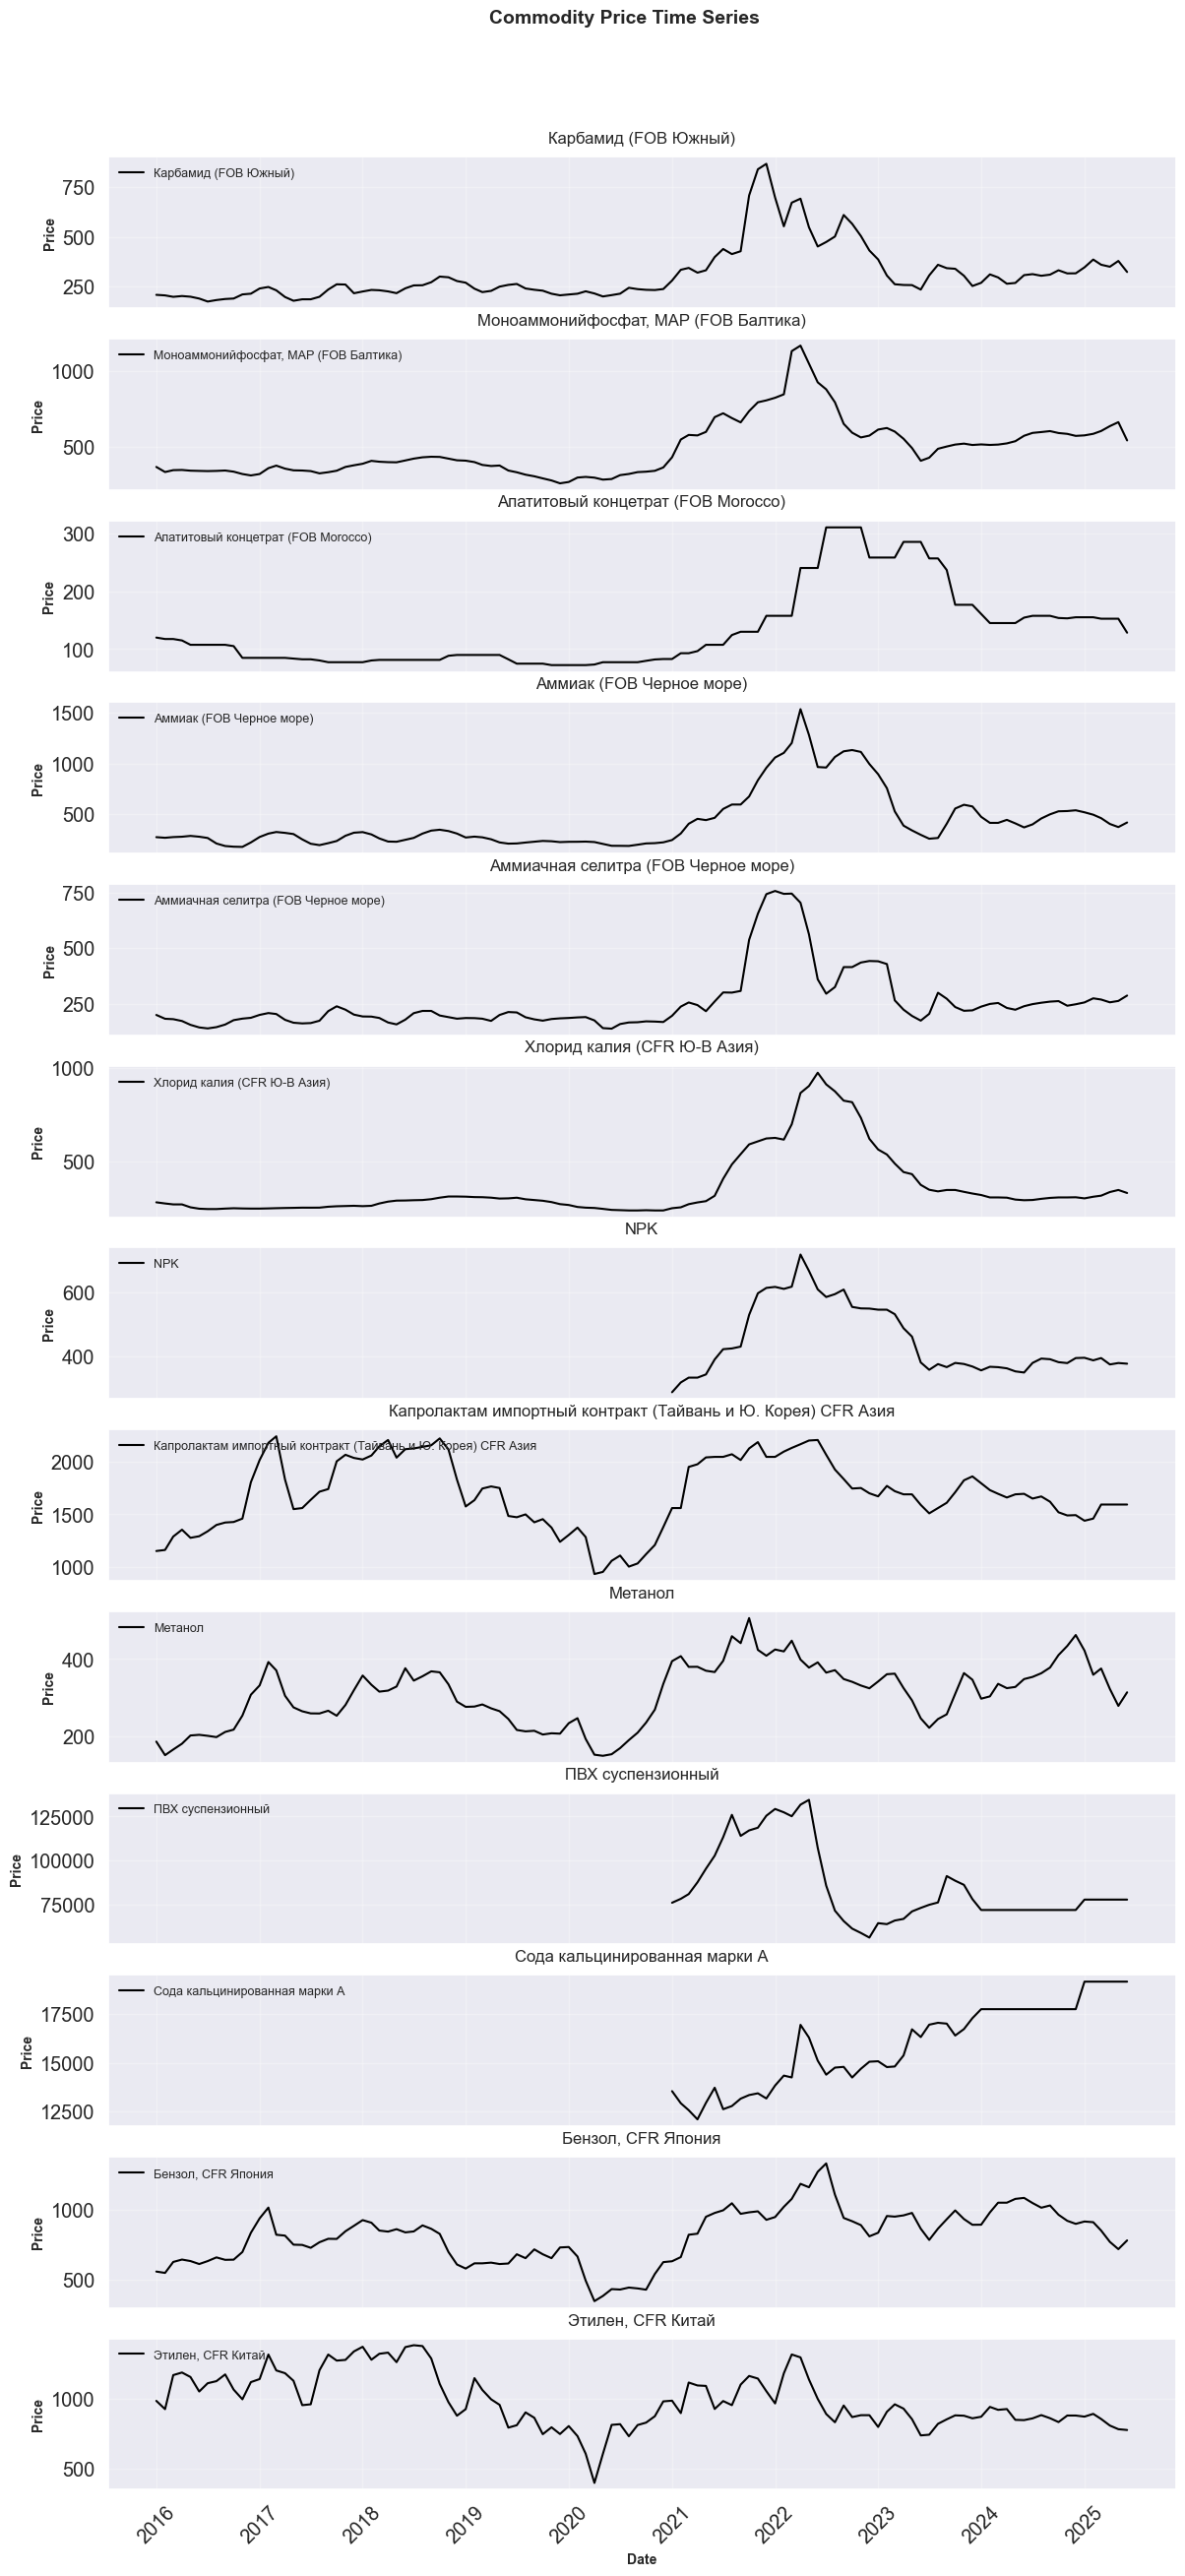

In [262]:
df = pd.read_csv("/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional/Data/chemicals.csv", index_col=0)
df.index = pd.to_datetime(df.index)
df = df.drop(columns=['Unnamed: 8', 'Unnamed: 9'])
visualize_ts(df, df.columns, figsize=(14, 30))

df = df.drop(columns=['NPK', 'ПВХ суспензионный', 'Сода кальцинированная марки А'])

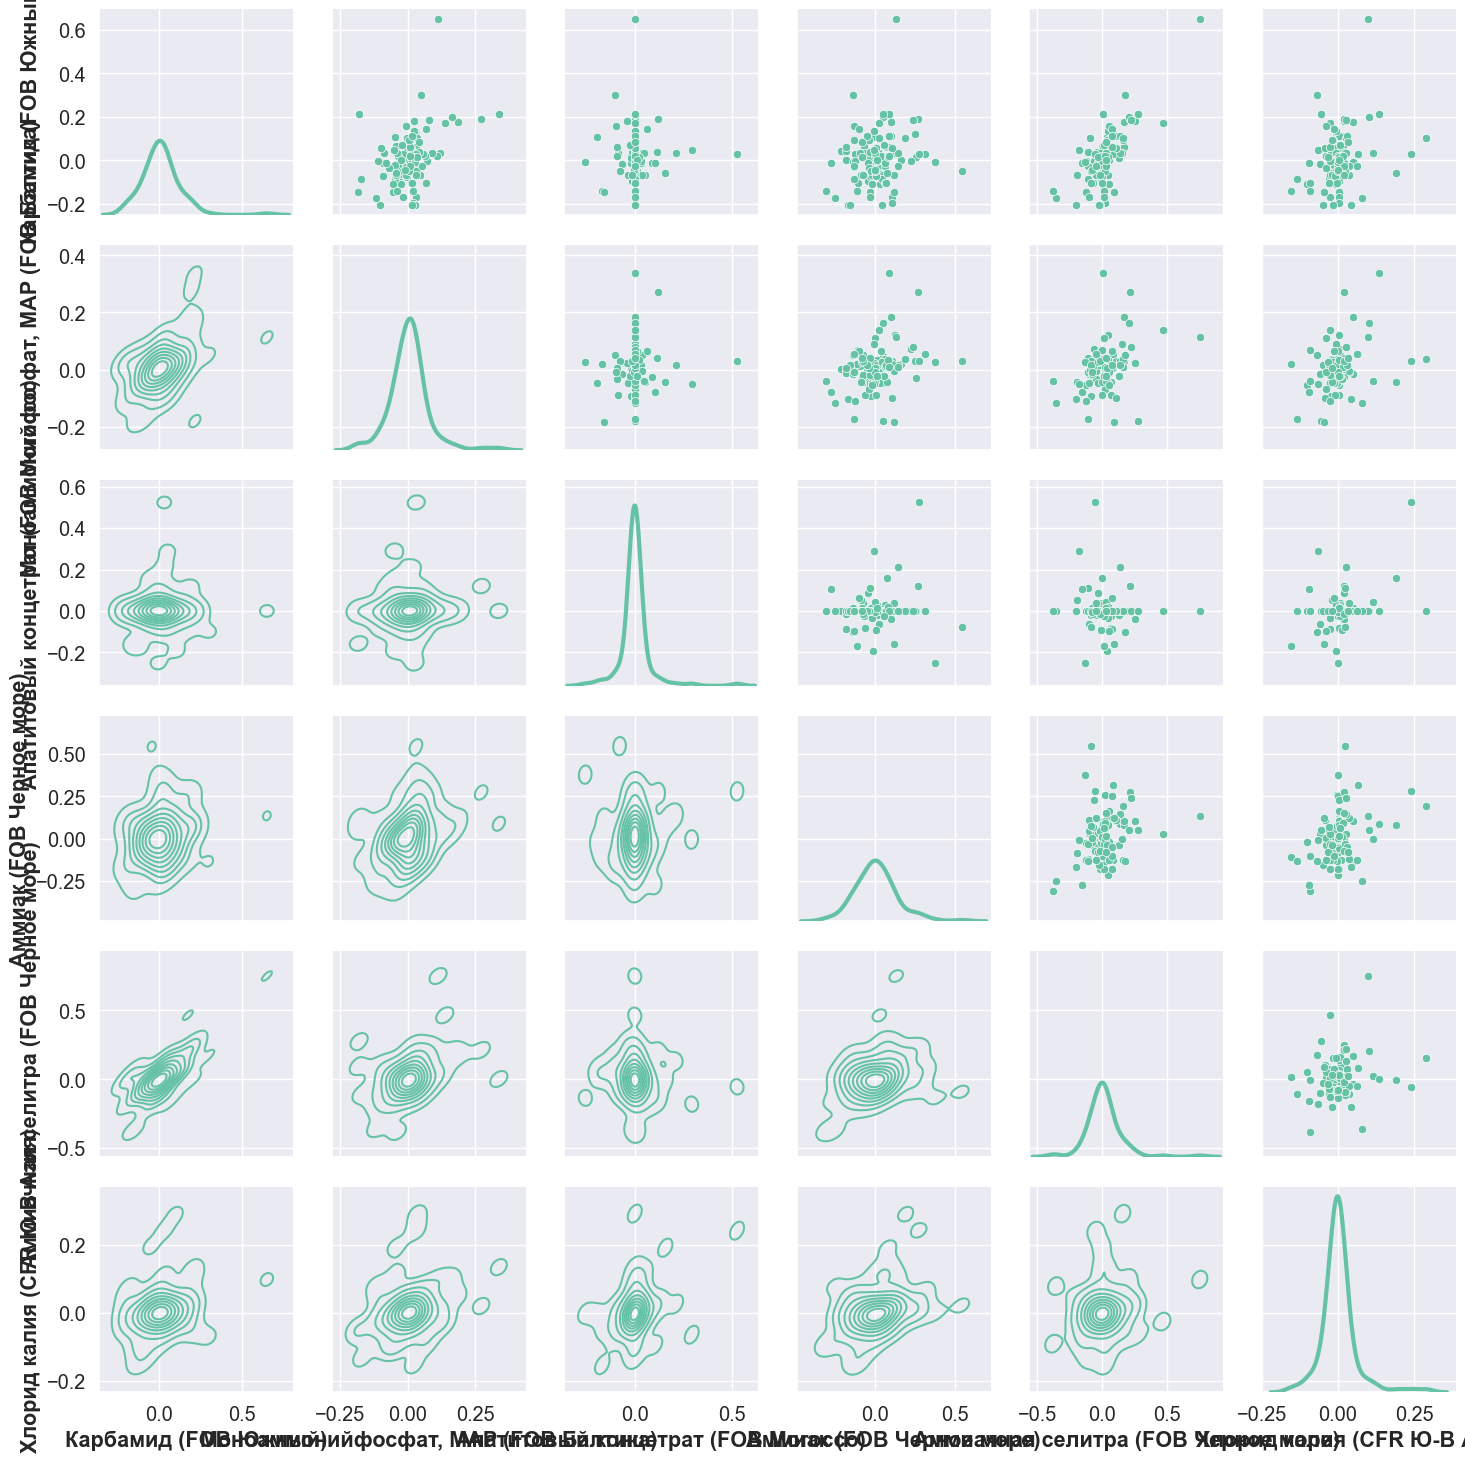

In [263]:
# log_rets_df = np.log(df).diff()
log_rets_df = df.pct_change()

g = sns.PairGrid(log_rets_df[df.columns[:6]])
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=3, legend=False)

### There is no significant correlation but some of the series seem to cointegrate
### DTW transformation should be helpful

(<Figure size 1400x3000 with 10 Axes>,
 array([<Axes: title={'center': 'Карбамид (FOB Южный)'}, ylabel='Price'>,
        <Axes: title={'center': 'Моноаммонийфосфат, MAP (FOB Балтика)'}, ylabel='Price'>,
        <Axes: title={'center': 'Апатитовый концетрат (FOB Morocco)'}, ylabel='Price'>,
        <Axes: title={'center': 'Аммиак (FOB Черное море)'}, ylabel='Price'>,
        <Axes: title={'center': 'Аммиачная селитра (FOB Черное море)'}, ylabel='Price'>,
        <Axes: title={'center': 'Хлорид калия (CFR Ю-В Азия)'}, ylabel='Price'>,
        <Axes: title={'center': 'Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия'}, ylabel='Price'>,
        <Axes: title={'center': 'Метанол'}, ylabel='Price'>,
        <Axes: title={'center': 'Бензол, CFR Япония'}, ylabel='Price'>,
        <Axes: title={'center': 'Этилен, CFR Китай'}, xlabel='Date', ylabel='Price'>],
       dtype=object))

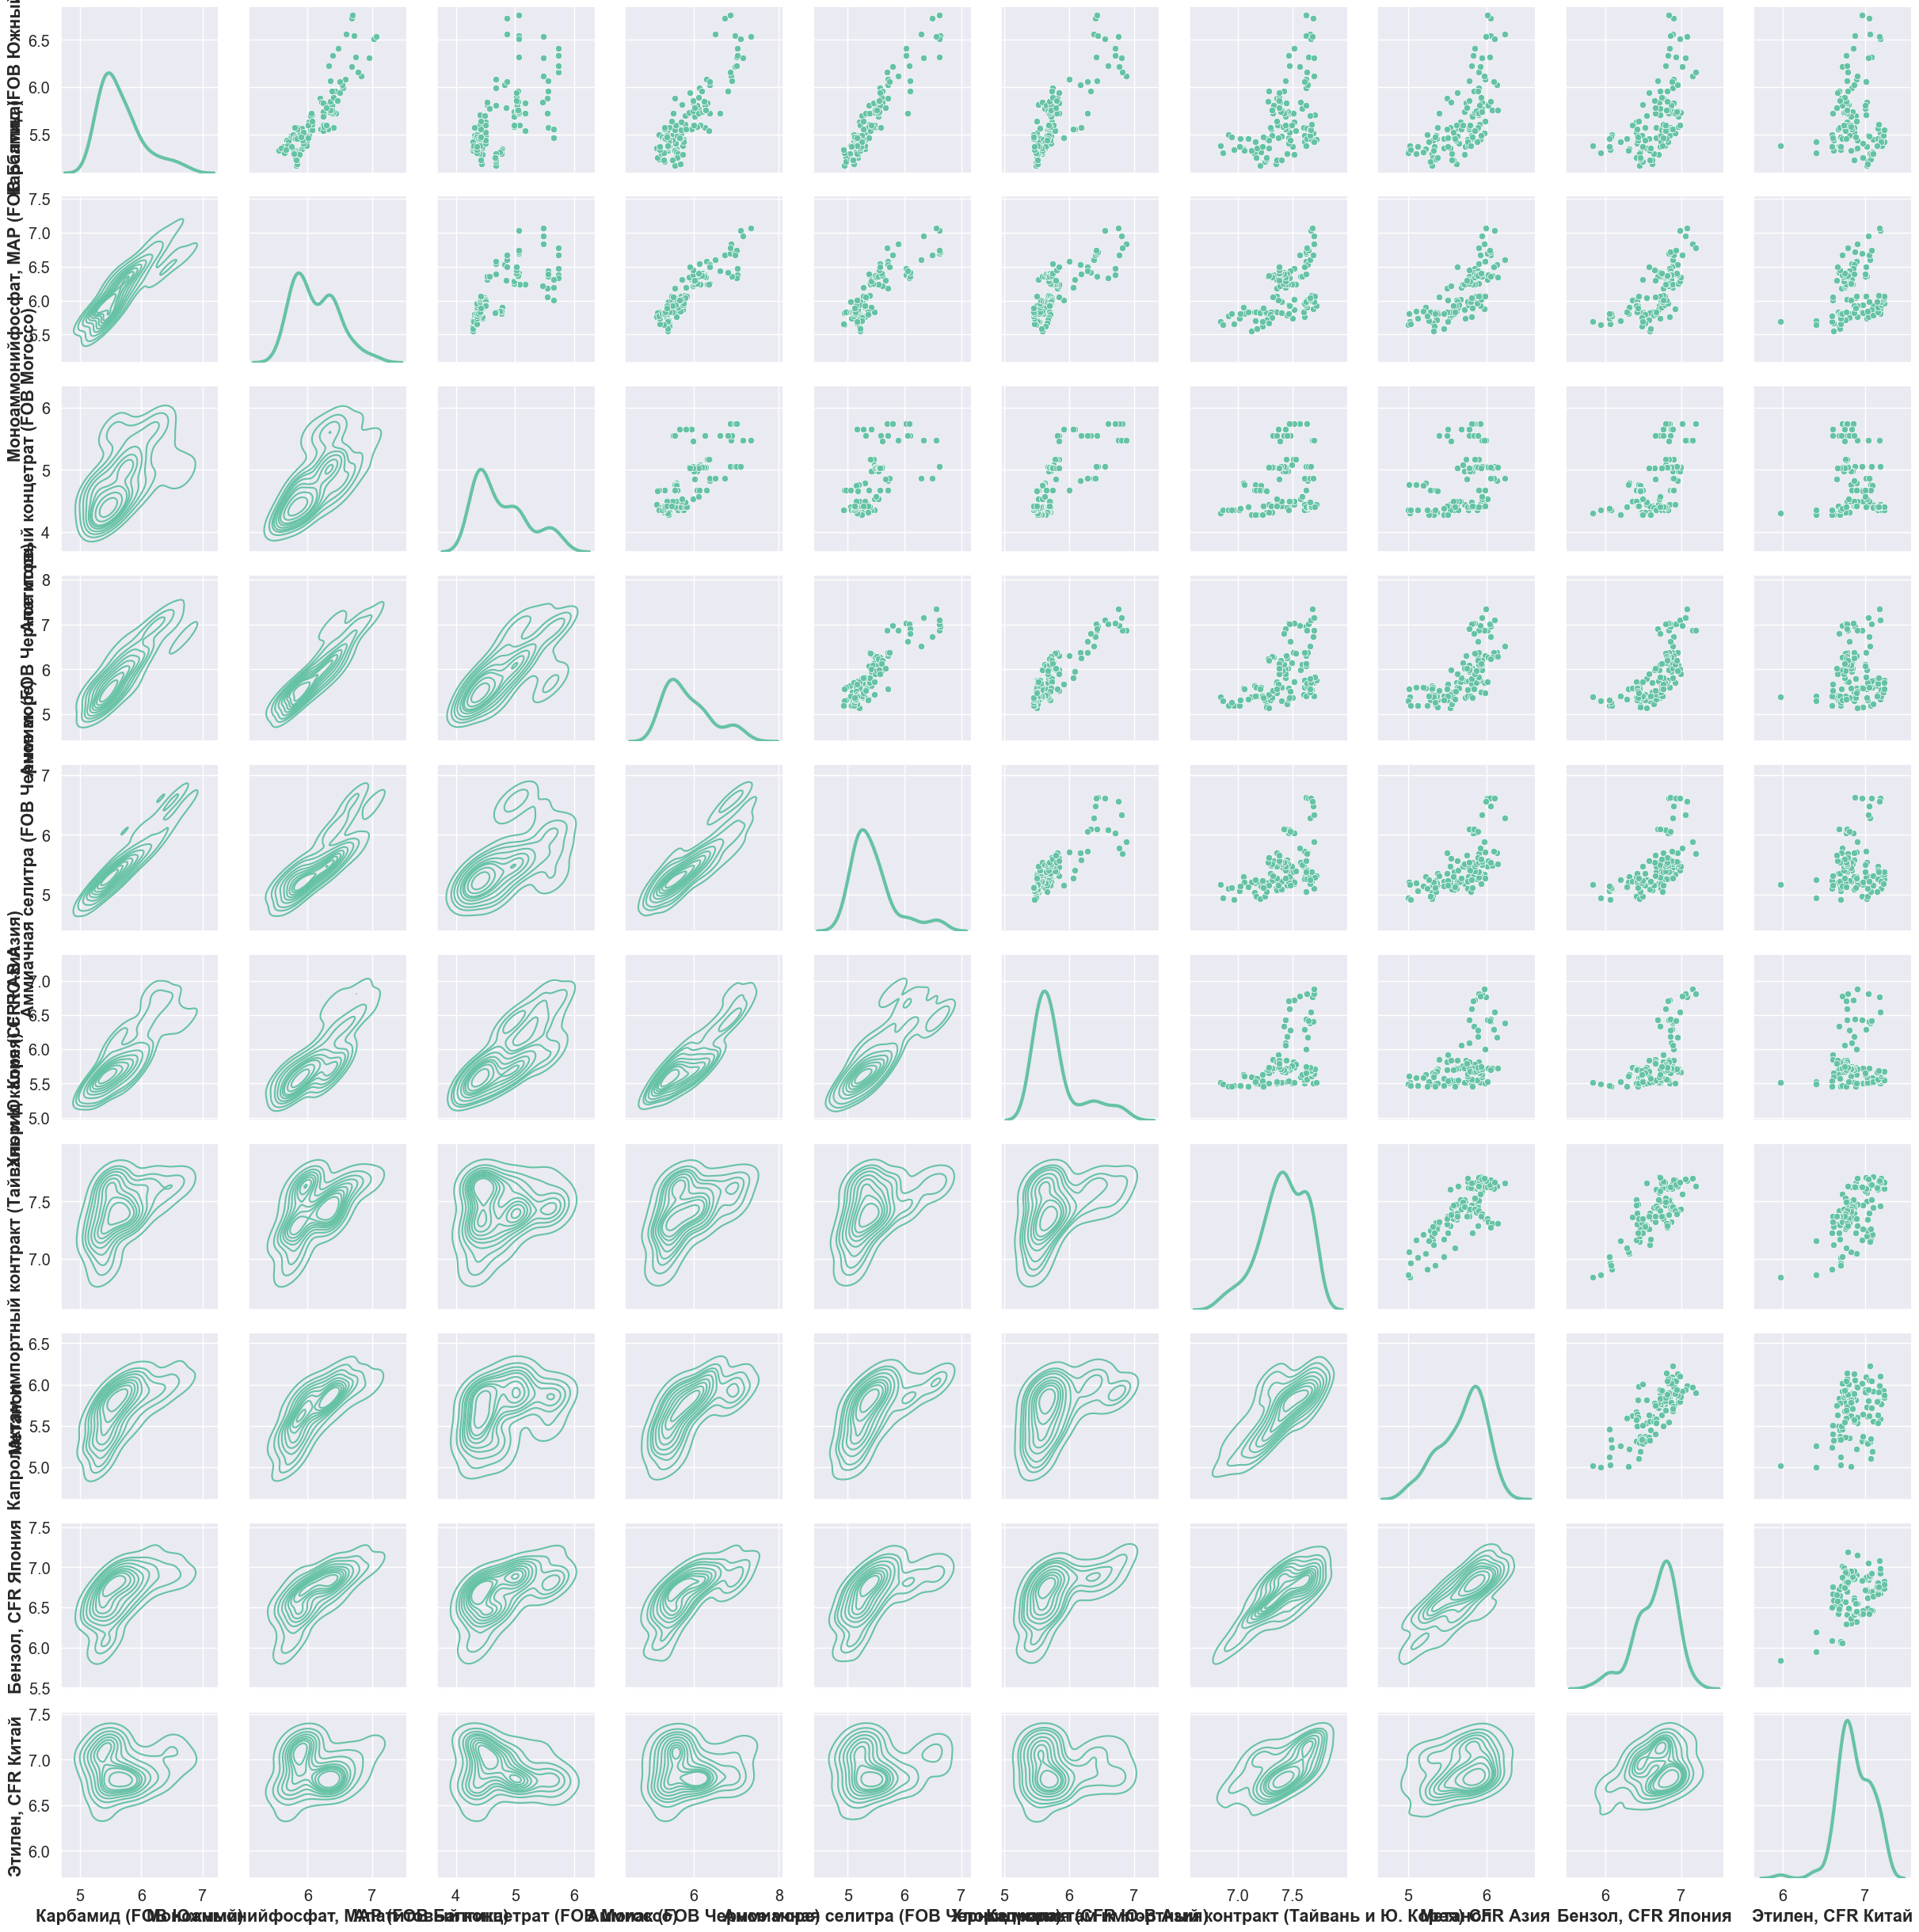

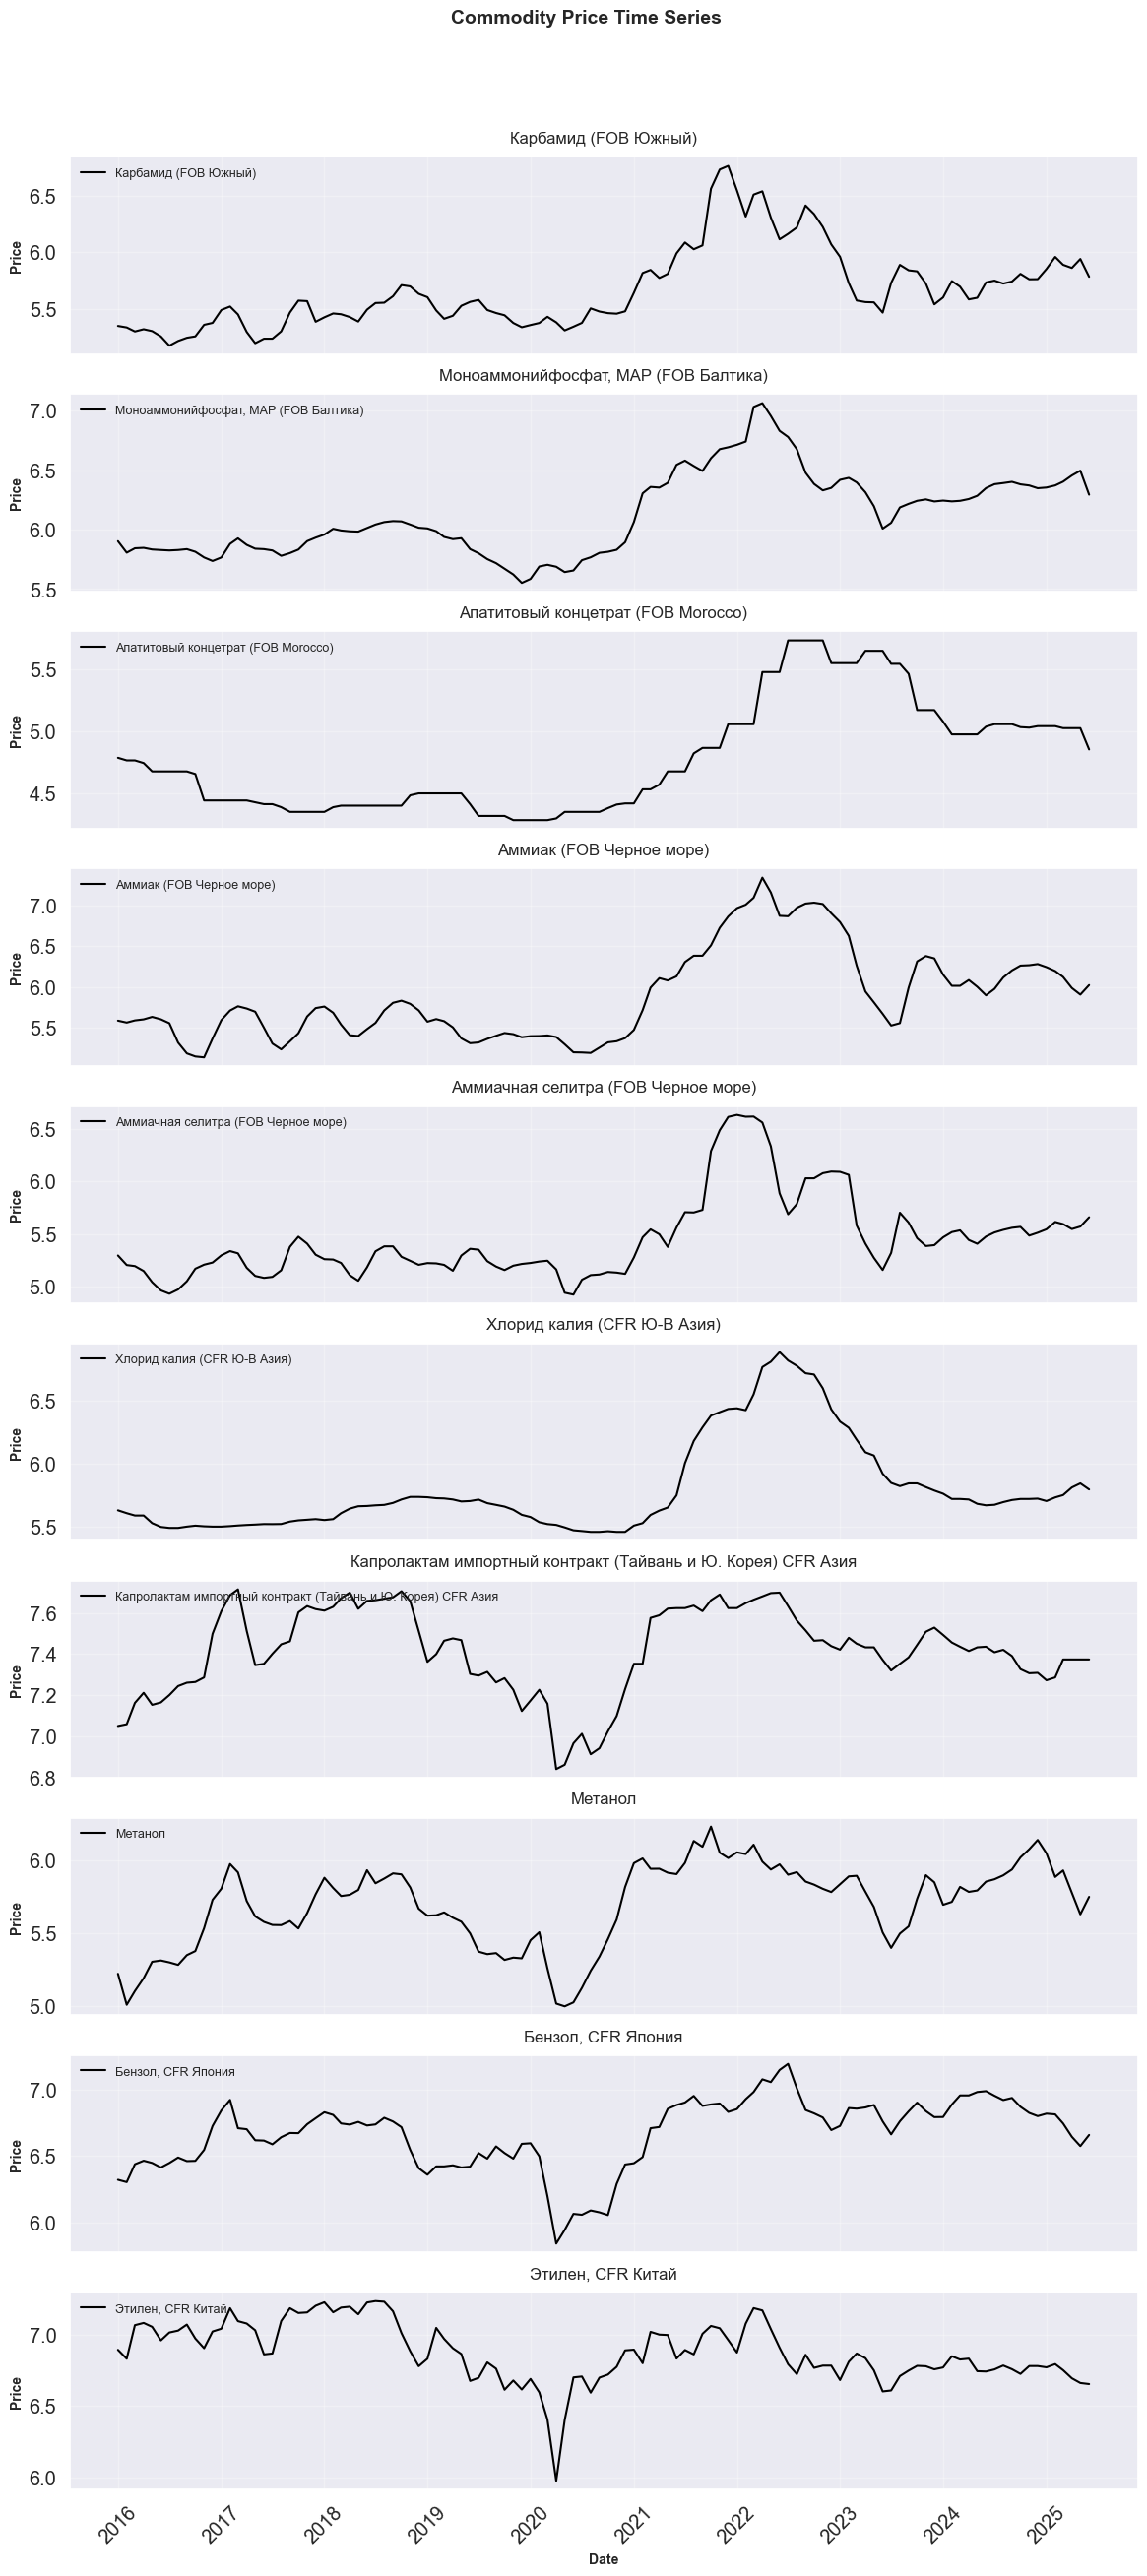

In [264]:
from darts.dataprocessing.transformers.boxcox import BoxCox

df_log = np.log(df)

g = sns.PairGrid(df_log)

g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=3, legend=False)

visualize_ts(df_log, df.columns, figsize=(14, 30))

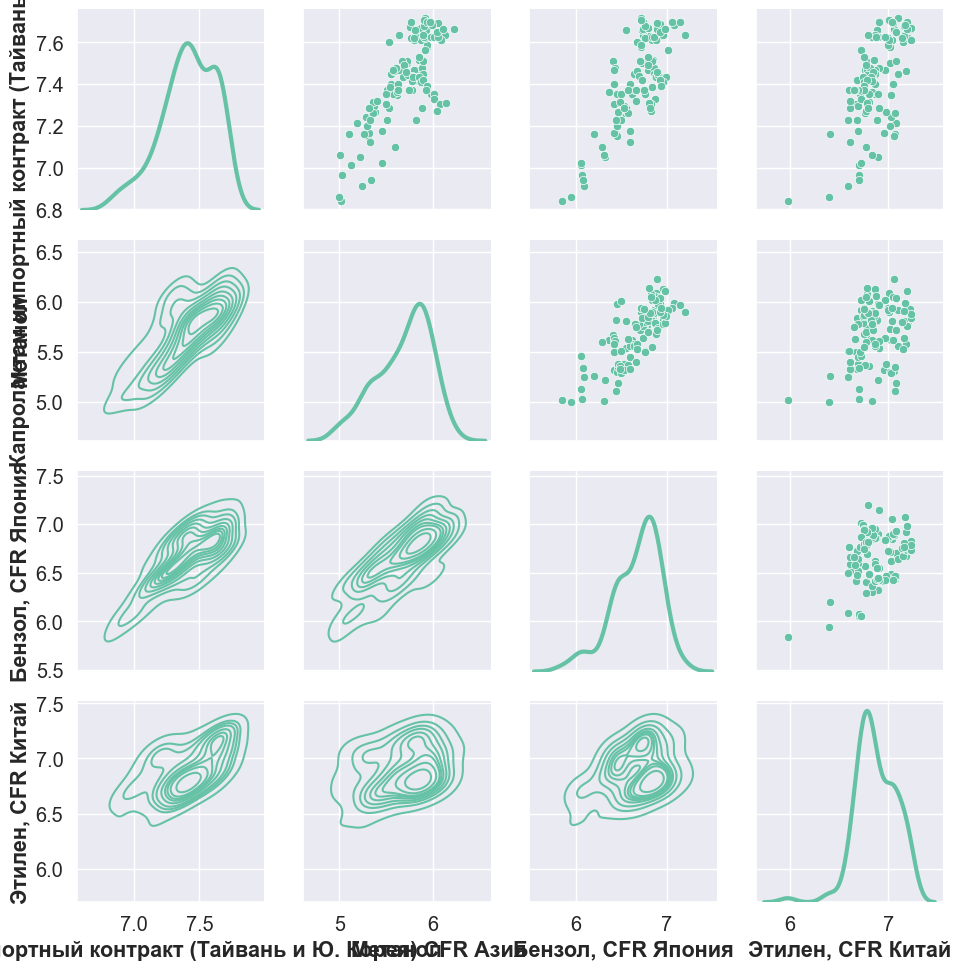

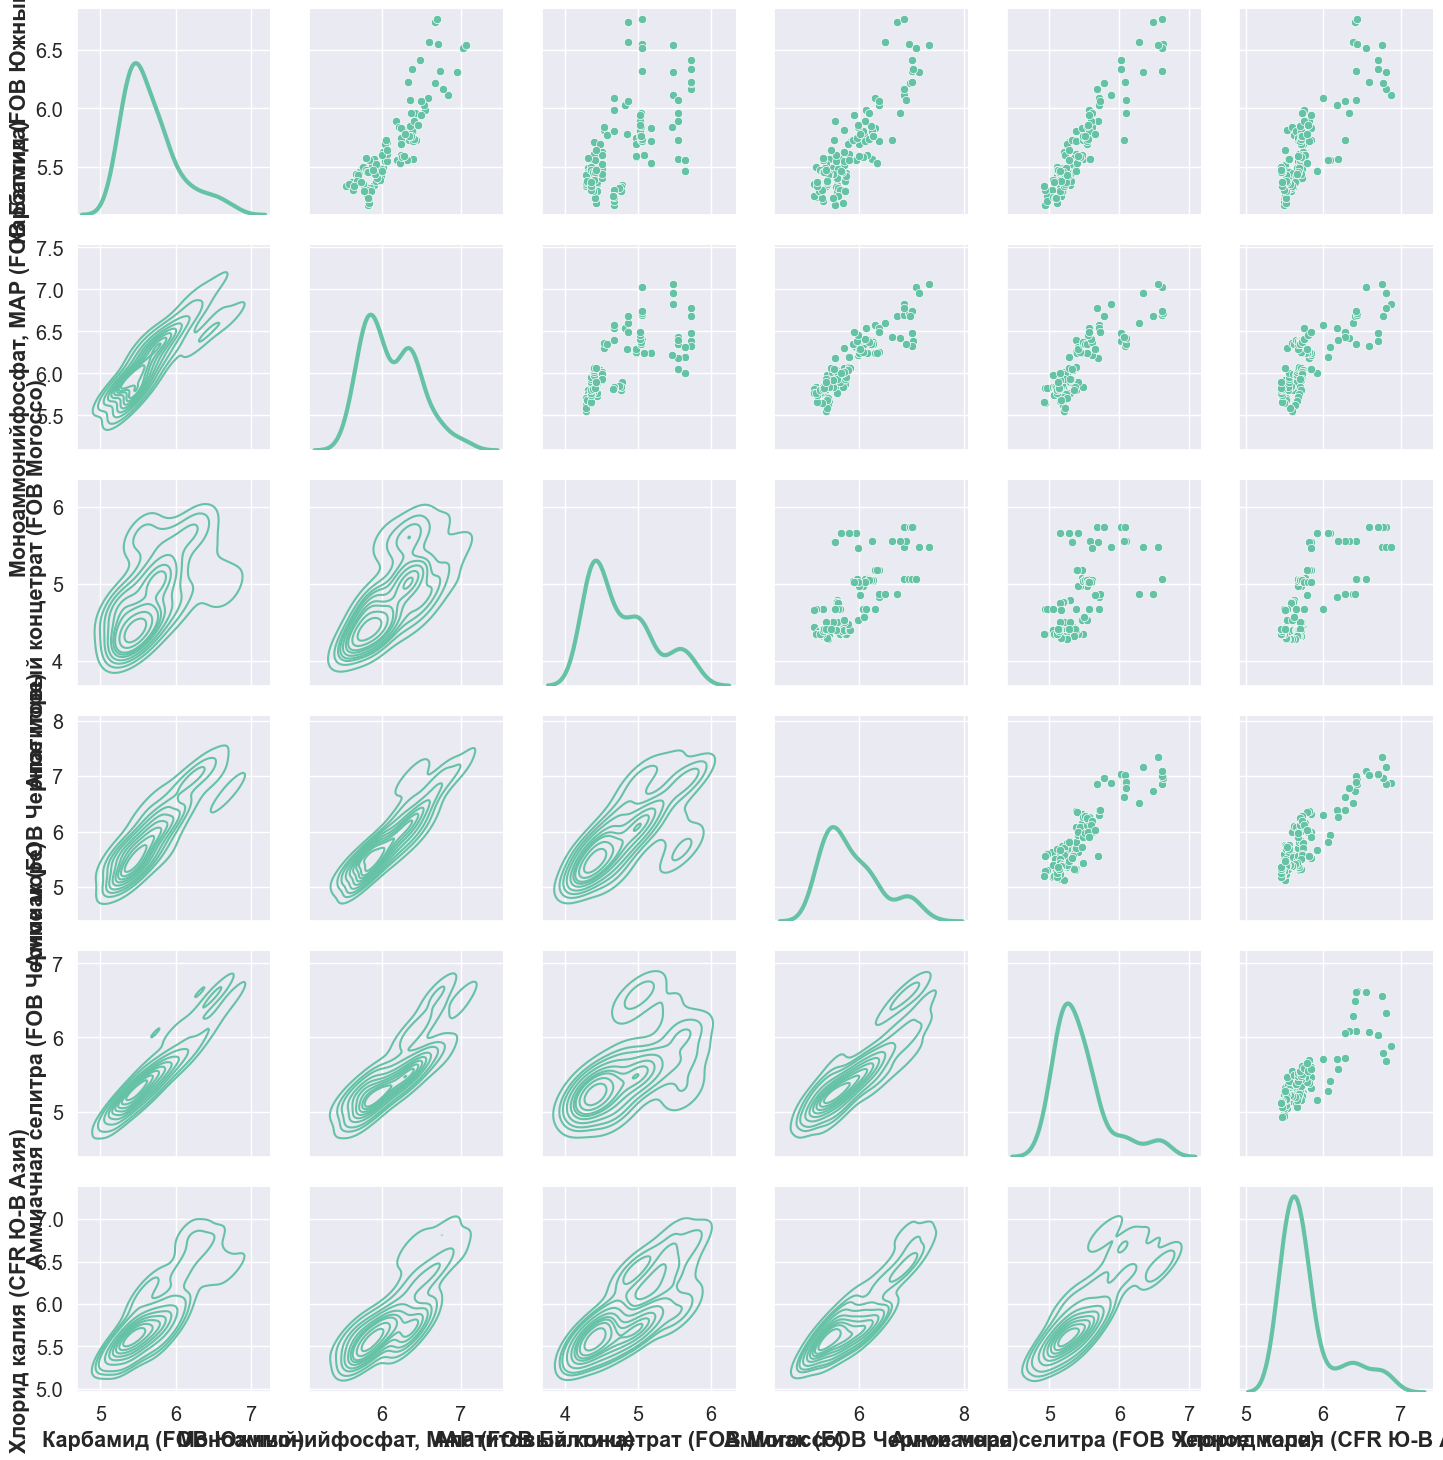

In [265]:
cluster_names_list = [df.columns[-4:], df.columns[:-4]]

for cluster_names in cluster_names_list:
    g = sns.PairGrid(df_log[cluster_names])
    g.map_upper(sns.scatterplot)
    g.map_lower(sns.kdeplot)
    g.map_diag(sns.kdeplot, lw=3, legend=False)

    # visualize_ts(df_log[cluster_names], cluster_names, figsize=(14, 30))
    


In [266]:
from darts import TimeSeries as ts
from sklearn.metrics import mean_absolute_percentage_error
from darts.metrics import mape
from darts.models import VARIMA


data = df[cluster_names_list[0]]

s = ts.from_dataframe(data)
train = s[:90]
test = s[90:]

In [267]:
# transformer = BoxCox(lmbda=0.2)
# transformed_train = transformer.fit_transform(train)
# transfomed_test = transformer.transform(test)
transformed_train = train
transfomed_test = test

model = VARIMA(p = 1, 
               d = 0,
               q = 0,
               trend=None
               )
model.fit(transformed_train, 
        #   future_covariates=future_cov
          )
pred = model.predict(n=24,
                    #  future_covariates=future_cov
                     )

/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


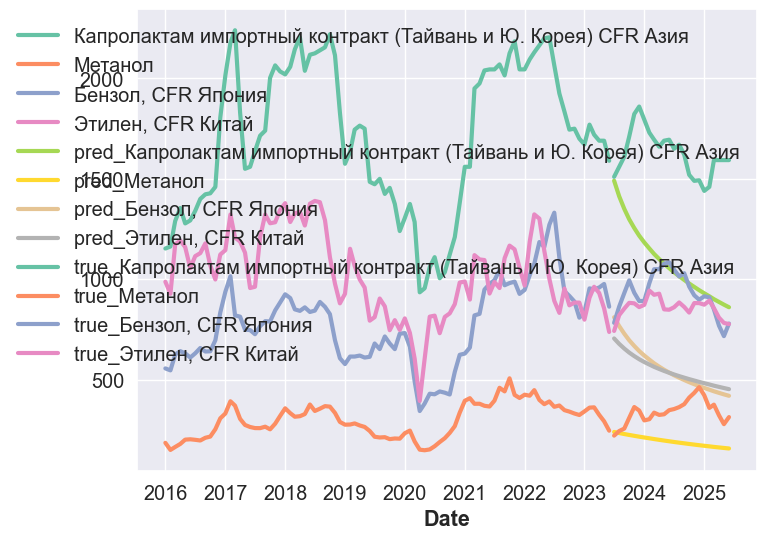

Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия
MAPE = 33.32069811641974 %
Метанол
MAPE = 41.04463326081406 %
Бензол, CFR Япония
MAPE = 39.92707559446284 %
Этилен, CFR Китай
MAPE = 36.2287395834936 %


In [268]:
plt.figure(figsize=(8,6))
transformed_train.plot(lw=3)
pred.plot(lw=3, label='pred')
transfomed_test.plot(lw=3, label='true')
plt.show()

for i in range(len(cluster_names_list[0])):
    test_val = transfomed_test.values()[:, i]
    pred_val = pred.values()[:, i]
    mape = mean_absolute_percentage_error(test_val, pred_val)
    print(cluster_names_list[0][i])
    print(f'MAPE = {mape * 100} %')


In [269]:
# # Transform back:

# for i in range(len(cluster_names_list[0])):
#     test_val = transformer.inverse_transform(transfomed_test).values()[:, i]
#     pred_val = transformer.inverse_transform(pred).values()[:, i]
#     mape = mean_absolute_percentage_error(test_val, pred_val)
#     print(cluster_names_list[0][i])
#     print(f'MAPE = {mape * 100} %')

Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия


/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


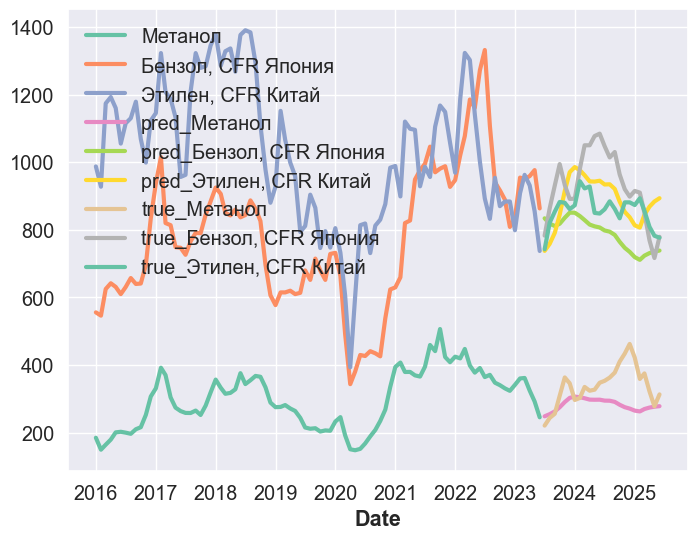

Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия
MAPE = 16.421377297563055 %
Метанол
MAPE = 15.323948524731703 %
Бензол, CFR Япония
MAPE = 7.064740182827983 %


In [270]:
print(data.columns[0])
s = ts.from_dataframe(data[data.columns[1:]])
future_cov = ts.from_series(data[data.columns[0]])
train = s[:90]
test = s[90:]

model = VARIMA(p = 1, 
               d = 0,
               q = 0,
               trend=None
               )
model.fit(train, 
          future_covariates=future_cov
          )
pred = model.predict(n=24,
                     future_covariates=future_cov
                     )

plt.figure(figsize=(8,6))
train.plot(lw=3)
pred.plot(lw=3, label='pred')
test.plot(lw=3, label='true')
plt.show()

for i in range(len(cluster_names_list[0])-1):
    test_val = test.values()[:, i]
    pred_val = pred.values()[:, i]
    mape = mean_absolute_percentage_error(test_val, pred_val)
    print(cluster_names_list[0][i])
    print(f'MAPE = {mape * 100} %')

/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


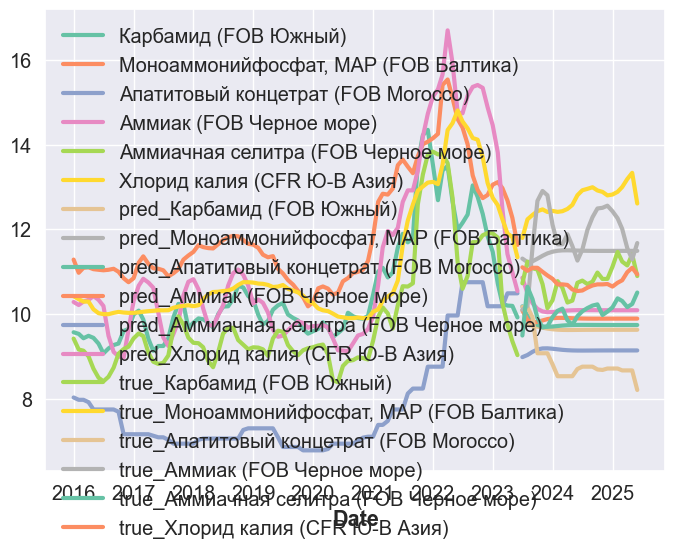

Карбамид (FOB Южный)
MAPE = 31.88931110434805 %
Моноаммонийфосфат, MAP (FOB Балтика)
MAPE = 29.859160567807514 %
Апатитовый концетрат (FOB Morocco)
MAPE = 38.91818142789021 %
Аммиак (FOB Черное море)
MAPE = 44.81749139749407 %
Аммиачная селитра (FOB Черное море)
MAPE = 27.22894491396628 %
Хлорид калия (CFR Ю-В Азия)
MAPE = 19.32371757571979 %


In [278]:
data = df[cluster_names_list[1]]

s = ts.from_dataframe(data)
train = s[:90]
test = s[90:]


transformer = BoxCox(lmbda=0.2)
transformed_train = transformer.fit_transform(train)
transfomed_test = transformer.transform(test)

model = VARIMA(p = 1, 
               d = 1,
               q = 0,
               trend=None
               )
model.fit(transformed_train, 
        #   future_covariates=future_cov
          )
pred = model.predict(n=24,
                    #  future_covariates=future_cov
                     )

plt.figure(figsize=(8,6))
transformed_train.plot(lw=3)
pred.plot(lw=3, label='pred')
transfomed_test.plot(lw=3, label='true')
plt.show()

for i in range(len(cluster_names_list[1])):
    test_val = transformer.inverse_transform(transfomed_test).values()[:, i]
    pred_val = transformer.inverse_transform(pred).values()[:, i]
    mape = mean_absolute_percentage_error(test_val, pred_val)
    print(cluster_names_list[1][i])
    print(f'MAPE = {mape * 100} %')


Карбамид (FOB Южный)


/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


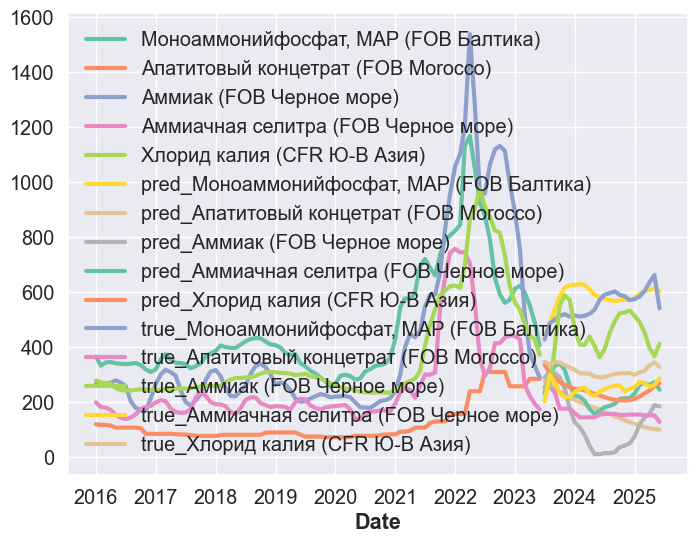

Карбамид (FOB Южный)
MAPE = 8.441992424501223 %
Моноаммонийфосфат, MAP (FOB Балтика)
MAPE = 19.80108120900761 %
Апатитовый концетрат (FOB Morocco)
MAPE = 70.90811073536058 %
Аммиак (FOB Черное море)
MAPE = 17.470265950371065 %
Аммиачная селитра (FOB Черное море)
MAPE = 23.172200361106242 %


In [280]:
print(data.columns[0])
s = ts.from_dataframe(data[data.columns[1:]])
future_cov = ts.from_series(data[data.columns[0]])
train = s[:90]
test = s[90:]


model = VARIMA(p = 1,
               d = 0,
               q = 0,
               trend=None
               )
model.fit(train, 
          future_covariates=future_cov
          )
pred = model.predict(n=24,
                     future_covariates=future_cov
                     )

plt.figure(figsize=(8,6))
train.plot(lw=3)
pred.plot(lw=3, label='pred')
test.plot(lw=3, label='true')
plt.show()

for i in range(len(cluster_names_list[1])-1):
    test_val = test.values()[:, i]
    pred_val = pred.values()[:, i]
    mape = mean_absolute_percentage_error(test_val, pred_val)
    print(cluster_names_list[1][i])
    print(f'MAPE = {mape * 100} %')